# Density Comparison — Papers vs Teams

Kernel-density estimate of each corpus over the shared joint-UMAP space, plotted
as `log2(teams_density / papers_density)`:

- **Red** = teams-dense relative to papers (iGEM activity ahead of the literature)
- **Blue** = papers-dense relative to teams (literature not yet adopted by iGEM)
- **White/neutral** = balanced coverage

This notebook also computes the **temporal precedence** of overlap-zone topics and
saves the tables consumed by `06-deliverables`.

> Run `compute_coords.ipynb` first.

In [1]:
# ── Make the shared aux/ package importable ───────────────────────────────────
# These notebooks live in 05-reporting/ alongside the aux/ package.
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

In [2]:
import matplotlib.pyplot as plt

from aux.paths import REPORTS_DIR, set_seed
from aux.coords import load_plot_data
from aux.density import (
    compute_density_ratio, draw_density_heatmap, topic_zones,
    curated_density_labels, dfprec_extreme_labels,
)
from aux.labels import add_density_labels
from aux.precedence import compute_precedence, save_precedence

set_seed()
df_papers, df_teams, XLIM, YLIM = load_plot_data()
papers_xy = df_papers[["x", "y"]].to_numpy()
teams_xy = df_teams[["x", "y"]].to_numpy()
print(f"Papers: {len(df_papers):,} | Teams: {len(df_teams):,}")

Papers: 24,202 | Teams: 4,707


## 1. Density-ratio grid

In [3]:
dens = compute_density_ratio(papers_xy, teams_xy, XLIM, YLIM, grid_res=300, bw=0.15)
print(f"Grid {dens['grid_res']}x{dens['grid_res']}, ratio clipped to ±{dens['vmax']:.2f}")

Grid 300x300, ratio clipped to ±20.57


## 2. Density-ratio heatmap (curated labels)

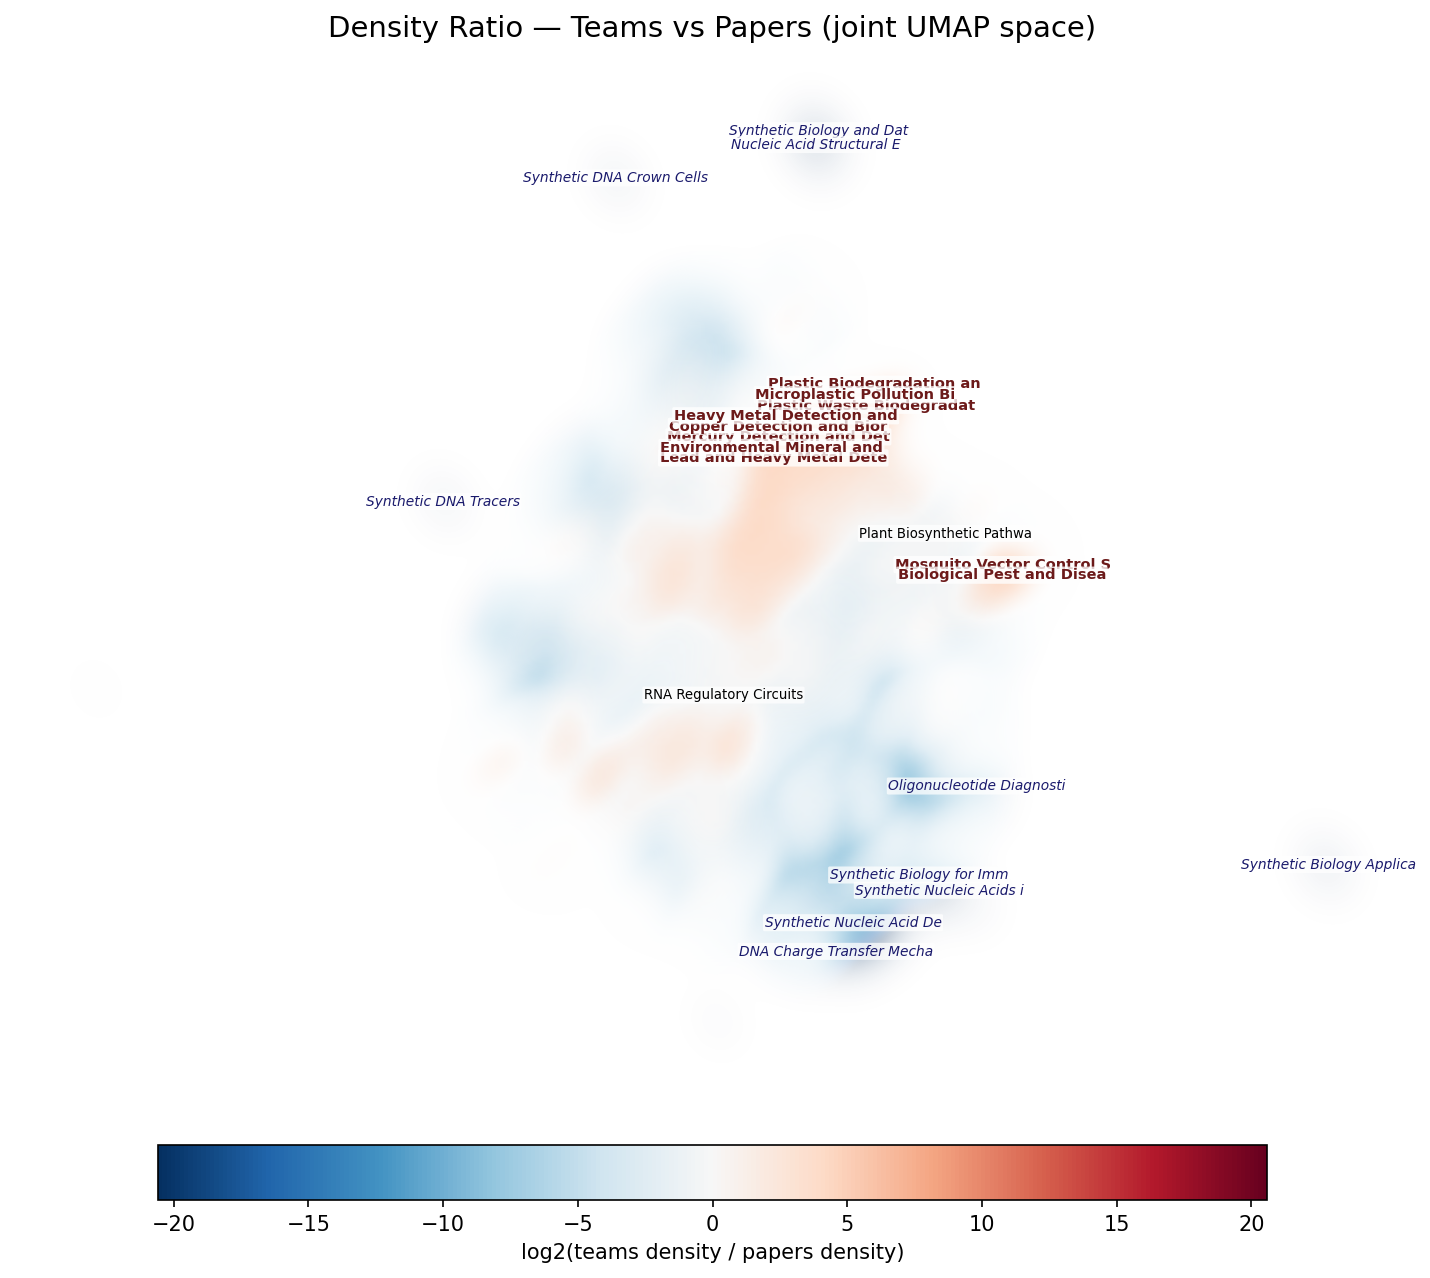

In [4]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
draw_density_heatmap(ax, dens, XLIM, YLIM)

papers_ctr = topic_zones(df_papers, "topic", "low_name", dens["ratio_interp"])
teams_ctr = topic_zones(df_teams, "topic", "low_name", dens["ratio_interp"])
add_density_labels(ax, curated_density_labels(papers_ctr, teams_ctr, n=10), XLIM, YLIM)

ax.set_title("Density Ratio — Teams vs Papers (joint UMAP space)", fontsize=14)
fig.savefig(REPORTS_DIR / "umap_density_ratio.png", dpi=220, bbox_inches="tight")
plt.show()

## 3. Temporal precedence of overlap topics

For each overlap-zone paper topic, find the teams nearby in the joint space and
compare year distributions. `delta_*_years < 0` → iGEM teams preceded the
literature; `> 0` → the literature preceded iGEM.

In [5]:
df_prec, papers_ctr, teams_ctr = compute_precedence(df_papers, df_teams, dens["ratio_interp"])
igem, lit = save_precedence(df_prec)

print("Papers topics by zone:", papers_ctr["zone"].value_counts().to_dict())
print(f"Overlap topics: {len(df_prec)} | iGEM-first: {len(igem)} | literature-first: {len(lit)}")
print(f"Saved → {REPORTS_DIR}: overlap_precedence_full.tsv, igem_preceded.tsv, literature_preceded.tsv")
df_prec.head(10)

Papers topics by zone: {'papers-only': 148, 'overlap': 83, 'teams-dominant': 32}
Overlap topics: 68 | iGEM-first: 34 | literature-first: 34
Saved → /Users/cristian/Desktop/GitHub/igem-synbio/assets/reports: overlap_precedence_full.tsv, igem_preceded.tsv, literature_preceded.tsv


,topic,global_name,n_papers,n_nearby_teams,papers_min_year,papers_q1_year,papers_mean_year,papers_median_year,papers_q3_year,papers_max_year,...,teams_mean_year,teams_median_year,teams_q3_year,teams_max_year,delta_min_years,delta_q1_years,delta_mean_years,delta_median_years,delta_q3_years,delta_max_years
0,259,CRISPR in Yeast Synthetic Biology,20,26,1997.0,2017.75,2019.60,2021.0,2024.0,2025.0,...,2013.62,2013.0,2014.75,2021.0,12.0,-6.75,-5.98,-8.0,-9.25,-4.0
1,169,CRISPR in Synthetic Biology,32,25,2015.0,2019.00,2021.34,2022.0,2024.0,2025.0,...,2016.20,2016.0,2021.00,2025.0,-7.0,-6.00,-5.14,-6.0,-3.00,0.0
2,50,Synthetic Biology of Living and Hybrid Materials,74,31,1984.0,2017.25,2019.64,2020.0,2024.0,2025.0,...,2015.06,2016.0,2018.00,2024.0,22.0,-6.25,-4.58,-4.0,-6.00,-1.0
3,142,SBOL Standardization and Data Sharing,37,10,2005.0,2015.00,2016.81,2016.0,2020.0,2024.0,...,2012.30,2012.0,2015.00,2017.0,3.0,-5.75,-4.51,-4.0,-5.00,-7.0
4,75,CRISPR Control Technologies,60,33,2014.0,2019.75,2021.77,2023.0,2025.0,2025.0,...,2017.36,2017.0,2019.00,2025.0,-4.0,-3.75,-4.41,-6.0,-6.00,0.0
5,62,Cellular Therapeutic Engineering,69,412,1977.0,2018.00,2019.55,2021.0,2024.0,2025.0,...,2015.48,2015.0,2019.00,2025.0,27.0,-7.00,-4.07,-6.0,-5.00,0.0
6,212,Microbial Chassis Development,25,8,2012.0,2016.00,2018.80,2018.0,2023.0,2024.0,...,2015.50,2015.5,2018.00,2025.0,-2.0,-5.00,-3.30,-2.5,-5.00,1.0
7,94,CRISPR-Based Bacterial Regulation,50,35,2007.0,2018.00,2020.18,2021.0,2024.0,2025.0,...,2017.09,2018.0,2019.00,2025.0,3.0,-2.50,-3.09,-3.0,-5.00,0.0
8,240,Tissue Engineering and Regenerative Medicine,21,51,2004.0,2017.00,2019.05,2020.0,2023.0,2025.0,...,2015.96,2017.0,2019.00,2024.0,2.0,-5.50,-3.09,-3.0,-4.00,-1.0
9,151,Plant Resilience Engineering,35,23,2006.0,2020.00,2022.00,2024.0,2025.0,2025.0,...,2019.13,2020.0,2023.00,2025.0,5.0,-5.00,-2.87,-4.0,-2.00,0.0


## 4. Density-ratio heatmap (precedence extremes)

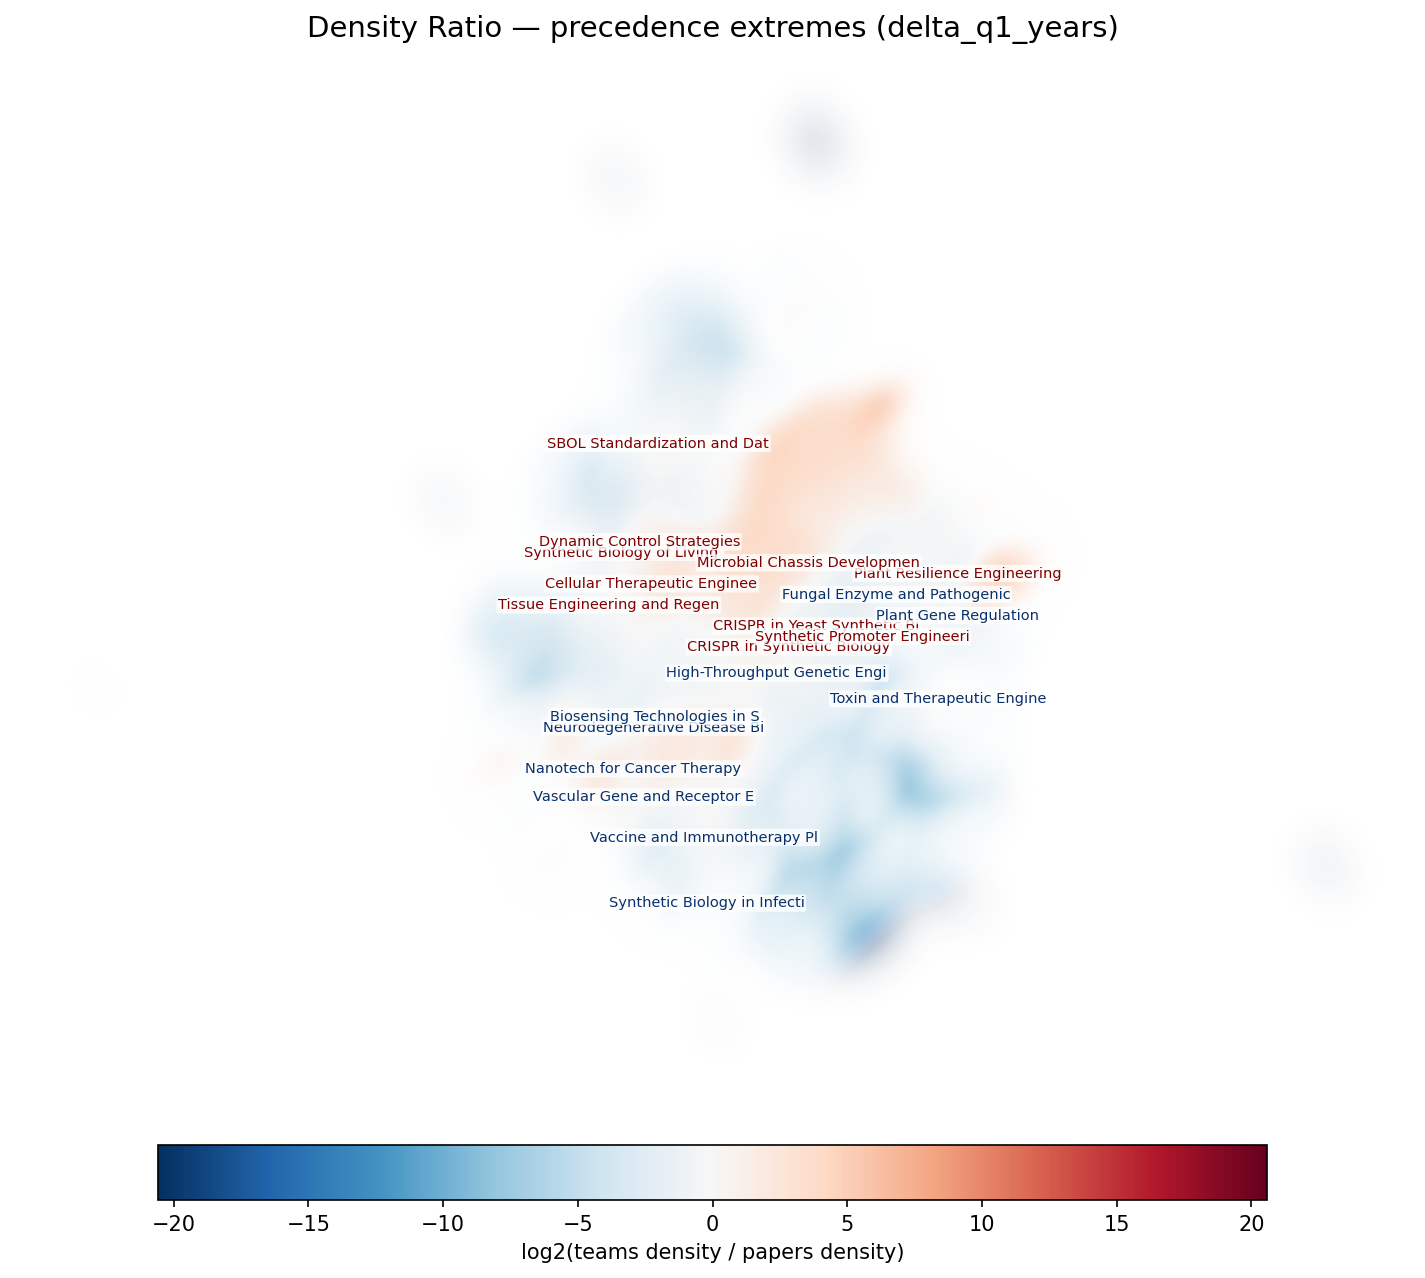

In [6]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
draw_density_heatmap(ax, dens, XLIM, YLIM)
add_density_labels(ax, dfprec_extreme_labels(df_prec, papers_ctr, n_extreme=10), XLIM, YLIM)

ax.set_title("Density Ratio — precedence extremes (delta_q1_years)", fontsize=14)
fig.savefig(REPORTS_DIR / "umap_density_ratio_extremes.png", dpi=220, bbox_inches="tight")
plt.show()